# Interactive Workshop – Self-Supervised Hydrophone Anomaly Detection

## Workshop Details
- **Goal**: Gain hands-on experience with self-supervised anomaly detection on hydrophone data. You will learn how to process audio data, train models without labels, and evaluate their ability to find unique ocean sounds.
- **Target Audience**: This workshop is designed for a diverse group, from ocean science professionals to machine learning enthusiasts. Whether you are a beginner or an expert, there are sections for you.
- **Prerequisites**: 
  - Basic familiarity with Python is helpful.
  - No deep learning experience required for the basics.
  - PyTorch experience is a plus for the advanced model customization sections.
- **Host**: Spencer Bialek
- **Date**: October 2025

## Structure
1. **Part 1**: Supervised vs. Self-Supervised Comparison (Concepts & Results).
2. **Part 2**: Building your own ONC dataset (Data Engineering).
3. **Part 3**: Training & Evaluation (Model Training).

## How to use this notebook
- **Run All**: You can run all cells in order to see the full workflow.
- **Step-by-Step**: We recommend stepping through each cell (Shift+Enter) to read the explanations and understand what's happening.
- **Markdown vs Code**: Text cells (like this one) explain the *why*, while code cells show the *how*.


<a id="top"></a>

# Table of Contents
- [Introduction to the concepts](#introduction-to-the-concepts)
- [1. Setup](#1-setup)
  - [Global paths and config](#global-paths-and-config)
- [Part 1 Supervised vs Self Supervised Comparison](#part-1-supervised-vs-self-supervised-comparison)
  - [1.0.0 Explore the Full Dataset](#100-explore-the-full-dataset)
  - [1.0.1 Define a fixed train/val/test split](#101-define-a-fixed-trainvaltest-split-on-the-full_h5-dataset)
  - [1.0.2 Create a small balanced dataset](#102-create-a-small-balanced-dataset-and-fixed-split-from-the-large-hdf5)
  - [1.1 Dataset Class: How we load the data](#11-dataset-and-labels-shared-by-cnn-and-ssamba)
  - [1.2 Dataloaders: Feeding the model](#12-dataloaders-and-class-imbalance-shared)
  - [1.3 The Model: A Small CNN](#13-supervised-cnn-model-and-optimizer)
  - [1.4 Training the CNN](#14-supervised-cnn-training-loop)
  - [1.5 Evaluating the CNN](#15-supervised-cnn-evaluation-on-full_h5)
  - [1.6 Fine-tuning SSAMBA (Self-Supervised Learning)](#16-ssamba-self-supervised-fine-tune-on-small)
  - [1.7 Comparing Results: CNN vs. SSAMBA](#17-unified-evaluation-cnn-vs-ssamba-on-full_h5)
- [Part 2 Build your own ONC dataset](#part-2-build-your-own-onc-dataset)
  - [2.1 List active hydrophones and choose a device](#21-list-active-hydrophones-and-choose-a-device)
  - [2.2 Download MAT and audio (FLAC) from ONC](#22-download-mat-and-audio-flac-from-onc)
  - [2.3 Parallel MAT downloads advanced](#23-parallel-mat-downloads-advanced)
  - [2.4 Label spectrograms with the Dash app](#24-label-spectrograms-with-the-dash-app)
  - [2.5 Make your own spectrograms from FLAC audio](#25-make-your-own-spectrograms-from-flac-audio)
  - [2.6 Use or build an HDF5 dataset](#26-use-or-build-an-hdf5-dataset)
  - [2.7 Create a fixed train val test split](#27-create-a-fixed-train-val-test-split)
  - [2.8 Create a SMALL_H5 quick start dataset](#28-create-a-small_h5-quick-start-dataset)
- [Train the self supervised model](#5-train-the-self-supervised-model)
  - [Customize the SSL tasks](#51-customize-the-ssl-tasks)
- [Evaluate your own audio file](#7-evaluate-your-own-audio-file-local-path)
- [Save or archive experiment outputs](#8-savearchive-experiment-outputs)
- [ROC and Precision Recall curves](#9-roc-and-precisionrecall-curves-replace-with-actual-results)
- [Next steps and resources](#10-next-steps-and-resources)

---



<a id="introduction-to-the-concepts"></a>

## Introduction to the concepts

We are going to explore a powerful way to find anomalies in ocean sounds without needing thousands of human labels.

### 1. What is Self-Supervised Learning (SSL)?
Imagine trying to learn a language by reading a book with some words blacked out. You have to guess the missing words based on the context. If you do this enough, you learn grammar and vocabulary without anyone teaching you explicitly.

**Self-Supervised Learning** works the same way for our hydrophone data:
- We take a spectrogram (a visual picture of sound).
- We hide small squares (patches) of the image.
- The model tries to guess what's in the hidden squares.
- By doing this millions of times, the model learns what "normal" ocean sounds look like (waves, rain, common ships).

### 2. What is Anomaly Detection?
Once the model knows what "normal" looks like, it gets surprised when it sees something unusual—like a whale call or a rare mechanical noise. We use this "surprise" (or high error in guessing) to flag anomalies.

### 3. The Workflow
1.  **Download**: Get raw audio data from Ocean Networks Canada.
2.  **Pretrain (SSL)**: Let the model learn patterns from unlabeled data.
3.  **Finetune**: Teach the model a specific task (like "Is this weird?") using a tiny amount of labeled data.
4.  **Evaluate**: See how well it works on new data.

### Key Terms
- **Spectrogram**: A graph with Time on the x-axis and Frequency (pitch) on the y-axis. Brighter colors mean louder sounds.
- **SSAMBA**: The specific model architecture we are using (Self-Supervised Audio Mamba). It's very good at handling long sequences of data.
- **Fine-tuning**: Taking a smart, pretrained model and giving it a quick lesson on a specific job.

![Spectrogram example](https://upload.wikimedia.org/wikipedia/commons/e/ec/2023-Mai-20_14h38min_Wien_aesserer_Lerchenfelder_G%C3%BCrtel_Thaliagasse_Sirene_autos_motorrad_Verkehrsdauer_zwei_Ampelphasen_SpektrumFFT.jpg)

*Spectrogram: time (x) vs frequency (y), color ≈ energy.*


<a id="1-setup"></a>

## 1. Setup

- Ensure you have Python 3.10+ and CUDA drivers (optional) installed.
- Recommended: create and activate a virtual environment.
- The cells below verify CUDA/Torch and set repo paths for imports.
- Data lives in two places: things you create go into `REPO_DIR/data`, and preloaded datasets/models live under `$HOME/data`. The code always prefers your copies when both exist.


In [1]:
import torch
print(f"torch version: {getattr(torch, '__version__', None)}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    try:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name} | CC: {props.major}.{props.minor}")
    except Exception as e:
        print('GPU props error:', repr(e))


torch version: 2.7.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU | CC: 8.9


In [ ]:
## Global paths and config

from pathlib import Path
import os
import sys
import subprocess


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / '.git').exists():
            return parent
    try:
        root = subprocess.check_output(['git', 'rev-parse', '--show-toplevel'], text=True).strip()
        return Path(root)
    except Exception:
        return start


REPO_DIR = find_repo_root()

# Where you create things during the workshop
USER_DATA_DIR = REPO_DIR / 'data'

# Where the server already has stuff waiting for you (datasets + trained models)
# We default to /home/user/data as per the workshop setup, but fallback to home if missing
SERVER_DATA_DIR = Path('/home/user/data')
if not SERVER_DATA_DIR.exists():
    SERVER_DATA_DIR = Path.home() / 'data'

SERVER_DATASETS_DIR = SERVER_DATA_DIR / 'datasets'
SERVER_MODELS_DIR = SERVER_DATA_DIR / 'trained_models'
SERVER_PRETRAIN_DIR = SERVER_MODELS_DIR / 'pretrain'
SERVER_FINETUNE_DIR = SERVER_MODELS_DIR / 'finetune'

# ---------------------------------------------------------------------------
# Main FULL dataset (always provided for you)
# ---------------------------------------------------------------------------
FULL_NAME = 'different_locations_incl_backgroundpipelinenormals_multilabel.h5'
DATASET_FULL_USER = USER_DATA_DIR / FULL_NAME
DATASET_FULL_SERVER = SERVER_DATASETS_DIR / FULL_NAME

# We always expect the FULL H5 to be provided on the server, but if you
# dropped a copy into the repo we'll happily use that instead.
# We will only be using the one pre-downloaded in the SERVER_DATA_DIR
DATASET_H5 = DATASET_FULL_SERVER

# ---------------------------------------------------------------------------
# SMALL dataset (you can create your own; server copy is a backup)
# ---------------------------------------------------------------------------
SMALL_NAME = 'different_locations_incl_backgroundpipelinenormals_multilabel_SMALL.h5'
SMALL_H5_USER = USER_DATA_DIR / SMALL_NAME
SMALL_H5_SERVER = SERVER_DATASETS_DIR / SMALL_NAME

if SMALL_H5_USER.exists():
    SMALL_H5 = SMALL_H5_USER
elif SMALL_H5_SERVER.exists():
    SMALL_H5 = SMALL_H5_SERVER
else:
    SMALL_H5 = SMALL_H5_USER  # default target if you create it later

# ONC API token and data directory
ONC_TOKEN = os.environ.get('ONC_TOKEN', '')
DATA_DIR = USER_DATA_DIR

# ---------------------------------------------------------------------------
# CNN paths (your experiments live in the repo; optional backup on server)
# ---------------------------------------------------------------------------
CNN_EXP_DIR = REPO_DIR / 'cnn_experiments'
CNN_BEST = CNN_EXP_DIR / 'cnn_best.pt'

# Optional prepared CNN checkpoint under $HOME/data if you decide to ship one
CNN_PREP_CKPT = SERVER_MODELS_DIR / 'cnn_baseline' / 'cnn_best.pt'

# ---------------------------------------------------------------------------
# SSL paths (pretrained backbone + finetune checkpoints)
# ---------------------------------------------------------------------------
SSL_EXP_DIR = REPO_DIR / 'ssamba_experiments_small'

# Pretrained model: prefer user copy (if they downloaded it), else server copy
# Note: The download script puts it directly in SERVER_PRETRAIN_DIR
PRETRAIN_CKPT_NAME = 'pretrain-joint_best_checkpoint.pth'
PRETRAIN_ARGS_NAME = 'args.pkl'

if (USER_DATA_DIR / 'trained_models' / 'pretrain' / PRETRAIN_CKPT_NAME).exists():
    SSL_PRETRAINED = USER_DATA_DIR / 'trained_models' / 'pretrain' / PRETRAIN_CKPT_NAME
    SSL_PRETRAIN_ARGS = USER_DATA_DIR / 'trained_models' / 'pretrain' / PRETRAIN_ARGS_NAME
else:
    SSL_PRETRAINED = SERVER_PRETRAIN_DIR / PRETRAIN_CKPT_NAME
    SSL_PRETRAIN_ARGS = SERVER_PRETRAIN_DIR / PRETRAIN_ARGS_NAME

# Finetuned SSL checkpoint: prefer your run in the repo, fall back to server
USER_FT_CKPT = SSL_EXP_DIR / 'models' / 'ft-avgtok_best_checkpoint.pth'
USER_FT_ARGS = SSL_EXP_DIR / 'args.pkl'

# The server copy is downloaded by the script to SERVER_FINETUNE_DIR
PREP_FT_CKPT = SERVER_FINETUNE_DIR / 'ft-avgtok_best_checkpoint.pth'
PREP_FT_ARGS = SERVER_FINETUNE_DIR / 'args.pkl'

if USER_FT_CKPT.exists():
    SSL_FT_CKPT = USER_FT_CKPT
    SSL_FT_ARGS = USER_FT_ARGS
elif PREP_FT_CKPT.exists():
    SSL_FT_CKPT = PREP_FT_CKPT
    SSL_FT_ARGS = PREP_FT_ARGS
else:
    SSL_FT_CKPT = USER_FT_CKPT  # placeholder; later cells will complain if missing
    SSL_FT_ARGS = USER_FT_ARGS

# Audio eval defaults
AUDIO_PATH = Path('')
CHECKPOINT_PATH = SSL_FT_CKPT

print('REPO_DIR =', REPO_DIR)
print('USER_DATA_DIR =', USER_DATA_DIR)
print('SERVER_DATA_DIR =', SERVER_DATA_DIR)
print('DATASET_H5 =', DATASET_H5)
print('SMALL_H5 (active) =', SMALL_H5)
print('CNN_EXP_DIR =', CNN_EXP_DIR)
print('SSL_EXP_DIR =', SSL_EXP_DIR)
print('SSL_PRETRAINED =', SSL_PRETRAINED)
print('SSL_FT_CKPT =', SSL_FT_CKPT)
print('SSL_FT_ARGS =', SSL_FT_ARGS)
print('ONC_TOKEN set:', bool(ONC_TOKEN))
print('DATA_DIR (where you write stuff) =', DATA_DIR)


REPO_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc
USER_DATA_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/data
SERVER_DATA_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/data
DATASET_H5 = /home/sbialek/ONC/selfsupervision_anomalies_onc/data/datasets/different_locations_incl_backgroundpipelinenormals_multilabel.h5
SMALL_H5 (active) = /home/sbialek/ONC/selfsupervision_anomalies_onc/data/datasets/different_locations_incl_backgroundpipelinenormals_multilabel_SMALL.h5
CNN_EXP_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/cnn_experiments
SSL_EXP_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments_small
SSL_PRETRAINED = /home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
SSL_FT_CKPT = /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments_small/models/ft-avgtok_best_checkpoint.pth
ONC_TO

In [3]:
import sys
repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.append(repo_str)
print('Repo on sys.path:', repo_str in sys.path, repo_str)


Repo on sys.path: True /home/sbialek/ONC/selfsupervision_anomalies_onc


<a id="part-1-supervised-vs-self-supervised-comparison"></a>

## Part 1 Supervised vs Self Supervised Comparison

This first part is all about **results**: we train a supervised CNN baseline, fine tune a self supervised SSAMBA model on the same small dataset, and then compare them on one shared test split.

The idea is to give you an intuition for how far you can get with a small labeled set plus a strong SSL backbone, before we dive into how to build your own dataset in Part 2.

Skip the monolithic cell above and use the smaller cells below. They explain each piece (dataset, dataloaders, training, eval) and are easier to tweak. If you want to plug in your own data, read the notes under each section.


In [6]:
# Imports and global constants for the CNN baseline
import os
import math
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
)

# Ensure experiment dir
CNN_EXP_DIR.mkdir(parents=True, exist_ok=True)

# Dataset stats from the large HDF5 (provided)
DS_MEAN = 51.506817
DS_STD = 13.638703
print(f"Dataset stats (GLOBAL) → mean={DS_MEAN:.6f}, std={DS_STD:.6f}")


Dataset stats (GLOBAL) → mean=51.506817, std=13.638703


### 1.0.0 Explore the Full Dataset

Before we split the data or create a smaller subset, let's take a look at what we are working with. We will inspect the HDF5 file structure, count the number of samples for each anomaly class, and visualize some spectrograms to see the diversity of sounds.


In [ ]:
# 1.0.0 Explore the Full Dataset
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure FULL_H5 is defined (it should be from global config)
FULL_H5 = Path(DATASET_H5)

if not FULL_H5.exists():
    print(f"Dataset not found: {FULL_H5}")
else:
    with h5py.File(str(FULL_H5), 'r') as f:
        print("HDF5 Keys:", list(f.keys()))
        
        # Load data handles (don't read all spectrograms into memory!)
        specs = f['spectrograms']
        labels = f['labels'][:] # Read all labels (small enough)
        
        # Decode label strings if available
        if 'label_strings' in f:
            # Decode bytes to strings
            def dec(x):
                return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
            label_strings = [dec(x) for x in f['label_strings'][:]]
            print(f"\nTotal samples: {len(label_strings)}")
            
            # Count classes
            from collections import Counter
            c = Counter(label_strings)
            print("\nClass counts:")
            for k, v in c.most_common():
                print(f"  {k}: {v}")
                
            # Identify unique classes for plotting
            unique_classes = sorted(list(c.keys()))
        else:
            print("No label strings found, using multi-hot labels.")
            unique_classes = [f"Class {i}" for i in range(labels.shape[1])]
            label_strings = None

        # Plot one example from each class
        print("\nVisualizing examples...")
        n_classes = len(unique_classes)
        cols = 4
        rows = (n_classes + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
        if rows * cols > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
        
        for i, cls_name in enumerate(unique_classes):
            # Find indices for this class
            if label_strings:
                idxs = [j for j, x in enumerate(label_strings) if x == cls_name]
            else:
                # Just pick the first one for multi-hot (simplified)
                idxs = np.where(labels[:, i] == 1)[0]
                
            if len(idxs) > 0:
                # Pick a random one
                idx = np.random.choice(idxs)
                spec = specs[idx] # Shape (512, 512, 1)
                
                ax = axes[i]
                # Squeeze to remove channel dim (512, 512)
                ax.imshow(spec.squeeze(), origin='lower', cmap='inferno', aspect='auto')
                # Shorten title if too long
                short_name = (cls_name[:20] + '..') if len(cls_name) > 20 else cls_name
                ax.set_title(f"{short_name}\n(n={len(idxs)})", fontsize=9)
                ax.axis('off')
            else:
                axes[i].axis('off')
                
        # Turn off remaining axes
        for j in range(i+1, len(axes)):
            axes[j].axis('off')
            
        plt.tight_layout()
        plt.show()


### 1.0.1 Define a fixed train/val/test split on the FULL_H5 dataset

**Why do we need a split?**
When training machine learning models, we must separate our data into three sets to ensure we are not "cheating":
1.  **Train (80%)**: The data the model learns from.
2.  **Validation (10%)**: Used to tune hyperparameters and stop training early if the model stops improving.
3.  **Test (10%)**: Held out completely until the very end to see how well the model performs on unseen data.

**Reproducibility**
We use a fixed random seed (`SPLIT_SEED = 42`) so that every time you run this notebook, you get the exact same split. This ensures that if you compare two models, you are comparing them on the same data.


In [ ]:
# 1.0.1 Define a fixed train/val/test split on the FULL_H5 dataset
import h5py, numpy as np
from pathlib import Path

FULL_H5 = Path(DATASET_H5)
SPLIT_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

print('Deriving fixed split from FULL_H5:', FULL_H5)
if not FULL_H5.exists():
    raise SystemExit(f'Full HDF5 not found: {FULL_H5}')

# --- Step 1: Load labels to identify normal vs anomalous samples ---
with h5py.File(str(FULL_H5), 'r') as f:
    N = f['spectrograms'].shape[0]
    print('Total samples:', N)
    
    # Try to use string labels if available, otherwise fallback to multi-hot
    if 'label_strings' in f:
        def dec(x):
            return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
        ls = [dec(s) for s in f['label_strings'][:]]
        # 'normal' label means normal, anything else is anomalous
        is_normal = np.array([s == 'normal' for s in ls], dtype=bool)
    else:
        labels = f['labels'][:]
        # Sum of 0 means no anomaly tags -> normal
        is_normal = (labels.sum(axis=1) == 0)

# --- Step 2: Create a random permutation of indices ---
a = np.arange(N, dtype=np.int64)
rng = np.random.RandomState(SPLIT_SEED)
rng.shuffle(a)

# --- Step 3: Slice the permutation into train/val/test ---
n_train = int(TRAIN_RATIO * N)
n_val = int(VAL_RATIO * N)
train_idx = a[:n_train]
val_idx   = a[n_train:n_train+n_val]
test_idx  = a[n_train+n_val:]

print(f'Split sizes → train:{len(train_idx)}, val:{len(val_idx)}, test:{len(test_idx)}')

# --- Step 4: Save the split to disk ---
split_path = REPO_DIR / 'data' / f'full_split_seed{SPLIT_SEED}.npz'
split_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(split_path, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
print('Saved split to:', split_path)

# Expose these variables for later cells to use
FULL_TRAIN_IDX, FULL_VAL_IDX, FULL_TEST_IDX = train_idx, val_idx, test_idx


### 1.0.2 Create a small balanced dataset (and fixed split) from the large HDF5

**Why a small dataset?**
The full dataset might be too large to process quickly during a workshop. We create a **subset** that is small enough to train on in minutes but complex enough to be interesting.

**Addressing Class Imbalance**
In the ocean, "normal" sounds (waves, rain) are very common, while "anomalies" (whales, gliders) are rare. If we just took a random sample, we might get 99% normal data and the model would just learn to predict "normal" all the time.
To fix this, we create a **balanced** subset:
1.  We pick a limited number of **normal** samples (e.g., 1000).
2.  We try to pick a fixed number of **anomalies** for each class (e.g., 20 per class).

This gives the model a better chance to learn what anomalies look like.


In [ ]:
# 1.0.2 Create a small balanced dataset (and fixed split) from the large HDF5

import h5py
import numpy as np
from pathlib import Path

# Use global config paths
FULL_H5 = Path(DATASET_H5)
# SMALL_H5 is defined in the global config cell

# --- Configuration ---
SEED = 42
ANOM_PER_CLASS = 20          # Target samples per anomaly class
NUM_NORMAL = 1000            # Number of normal samples to include
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

rng = np.random.RandomState(SEED)

print('Preparing SMALL dataset from:', FULL_H5)
if not FULL_H5.exists():
    print(f"Full HDF5 not found: {FULL_H5}")
else:
    with h5py.File(str(FULL_H5), 'r') as src:
        specs = src['spectrograms']
        labels = src['labels'][:]             # multi-hot
        sources = src['sources'][:] if 'sources' in src else None
        label_strings = src['label_strings'][:] if 'label_strings' in src else None

        print(f"Source shapes → spectrograms={specs.shape}, labels={labels.shape}")

        # --- Step 1: Identify Normal vs Anomalous ---
        if label_strings is not None:
            print('Using label_strings for normal/anomalous split...')
            def dec(x):
                return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
            ls = [dec(s) for s in label_strings]
            is_normal = np.array([(s == 'normal') for s in ls], dtype=bool)
        else:
            print('Using multi-hot labels for normal/anomalous split...')
            is_normal = (labels.sum(axis=1) == 0)

        # --- Step 2: Restrict to Train+Val pool (Prevent Test Leakage) ---
        # We only pick samples that are in the FULL train or validation sets.
        # This ensures that when we later evaluate on the FULL test set, we haven't seen those samples.
        if 'FULL_TRAIN_IDX' in globals() and 'FULL_VAL_IDX' in globals():
            pool = np.concatenate([FULL_TRAIN_IDX, FULL_VAL_IDX]).astype(np.int64)
            pool = np.unique(pool)
            print(f"Restricting selection to train+val pool of size {len(pool)}")
        else:
            pool = np.arange(labels.shape[0], dtype=np.int64)

        normal_idx = np.intersect1d(np.where(is_normal)[0], pool)
        anom_idx   = np.intersect1d(np.where(~is_normal)[0], pool)
        print(f"Found (in pool) → normal:{len(normal_idx)}, anomalous:{len(anom_idx)}")

        if len(normal_idx) == 0 or len(anom_idx) == 0:
            print('Dataset lacks one of the classes; adjust selection.')
        else:
            # --- Step 3: Balanced Sampling ---
            # Pick ~ANOM_PER_CLASS per anomaly type
            C = labels.shape[1]
            anom_union = set()
            picked_per_class = []
            for c in range(C):
                pos_c = np.intersect1d(np.where(labels[:, c] == 1)[0], pool)
                rng.shuffle(pos_c)
                take_c = pos_c[:min(ANOM_PER_CLASS, len(pos_c))]
                picked_per_class.append(len(take_c))
                anom_union.update(take_c.tolist())
            anom_sel = np.array(sorted(anom_union), dtype=np.int64)
            print(f"Picked anomalies per class: {picked_per_class} → unique anomalous samples: {len(anom_sel)}")

            # Pick limited normals
            rng.shuffle(normal_idx)
            sel_normal = normal_idx[:min(NUM_NORMAL, len(normal_idx))]

            selected = np.concatenate([sel_normal, anom_sel])
            rng.shuffle(selected)

            # --- Step 4: Create Splits for Small Dataset ---
            n = len(selected)
            print(f"Selected total={n} → normal={len(sel_normal)}, anomalous={len(anom_sel)}")
            n_train = int(TRAIN_RATIO * n)
            n_val   = int(VAL_RATIO * n)
            n_test  = n - n_train - n_val
            train_sel = selected[:n_train]
            val_sel   = selected[n_train:n_train+n_val]
            test_sel  = selected[n_train+n_val:]
            print(f"Split sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")

            # --- Step 5: Write to HDF5 ---
            if SMALL_H5_USER.exists():
                print(f"Overwriting existing file: {SMALL_H5_USER}")
                SMALL_H5_USER.unlink()
            
            with h5py.File(str(SMALL_H5_USER), 'w') as dst:
                print('Creating output file and copying metadata...')
                # Allocate spectrograms dataset first
                dset = dst.create_dataset('spectrograms', shape=(n, 512, 512, 1), dtype=np.float32, compression='gzip', compression_opts=4, chunks=(64, 512, 512, 1))
                
                # Copy labels
                dst.create_dataset('labels', data=labels[selected], dtype=labels.dtype)
                
                # Copy string labels if available
                if label_strings is not None:
                    maxlen = int(np.max([len(str(s)) for s in label_strings[selected]])) if len(selected) > 0 else 10
                    lbl_arr = np.array([str(s).encode('utf-8') for s in label_strings[selected]], dtype=f'S{maxlen}')
                    dst.create_dataset('label_strings', data=lbl_arr)
                
                if sources is not None:
                    maxlen_src = int(np.max([len(str(s)) for s in sources[selected]])) if len(selected) > 0 else 10
                    src_arr = np.array([str(s).encode('utf-8') for s in sources[selected]], dtype=f'S{maxlen_src}')
                    dst.create_dataset('sources', data=src_arr)

                # Store split indices relative to this small file (0..n-1)
                inv_map = {orig: i for i, orig in enumerate(selected.tolist())}
                dst.create_dataset('index_map_original', data=selected, dtype=np.int64)
                dst.create_dataset('split/train_idx', data=np.array([inv_map[i] for i in train_sel], dtype=np.int64))
                dst.create_dataset('split/val_idx', data=np.array([inv_map[i] for i in val_sel], dtype=np.int64))
                dst.create_dataset('split/test_idx', data=np.array([inv_map[i] for i in test_sel], dtype=np.int64))
                
                # Save metadata attributes
                dst.attrs['seed'] = SEED
                dst.attrs['train_ratio'] = TRAIN_RATIO
                dst.attrs['val_ratio'] = VAL_RATIO
                dst.attrs['test_ratio'] = TEST_RATIO

                # --- Efficient Batch Copying ---
                print('Copying spectrograms in batches...')
                batch_size = 64
                num_batches = (n + batch_size - 1) // batch_size
                
                for b in range(num_batches):
                    s = b * batch_size
                    e = min(n, (b + 1) * batch_size)
                    
                    # Indices in the original large dataset
                    idx_block = selected[s:e]
                    
                    # h5py reads are much faster if indices are sorted
                    sorted_idx = np.sort(idx_block)
                    
                    # Read the block
                    block = specs[sorted_idx]
                    
                    # Reorder to match the random shuffle order in 'selected'
                    # np.searchsorted finds where each element of idx_block fits in sorted_idx
                    order = np.searchsorted(sorted_idx, idx_block)
                    
                    # Write to the new dataset
                    dset[s:e] = block[order]
                    
                    if (b % 5 == 0) or (b == num_batches - 1):
                        print(f"  wrote {e}/{n} ({int(100*e/n)}%)", flush=True)

            print(f"Wrote small dataset: {SMALL_H5_USER}")
            print(f"Sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")


<a id="11-dataset-and-labels-shared-by-cnn-and-ssamba"></a>

### 1.1 Dataset Class: How we load the data

In PyTorch, a `Dataset` class tells the computer how to get a single data sample. Here, `SmallH5BinaryDataset` does three things:
1.  **Opens the HDF5 file**: It knows where the data lives.
2.  **Gets a spectrogram**: When asked for item `i`, it loads the `i`-th spectrogram.
3.  **Normalizes it**: It subtracts the mean and divides by the standard deviation (z-score normalization) to help the model learn faster.
4.  **Returns Tensors**: It converts the data into PyTorch `Tensors` (matrices) that the GPU can understand.

**Bring your own data:**
If you want to use your own data later, you just need to create a class like this that returns `(image_tensor, label)`.


In [8]:
class SmallH5BinaryDataset(Dataset):
    def __init__(self, h5_path: Path, split: str, dataset_mean: float, dataset_std: float):
        assert split in ('train','val','test')
        self.h5_path = str(h5_path)
        self.split = split
        self.dataset_mean = float(dataset_mean)
        self.dataset_std = float(dataset_std)
        
        # Open file once to get indices and labels
        with h5py.File(self.h5_path, 'r') as f:
            self.idx = f[f'split/{split}_idx'][:]
            self.labels_multi = f['labels'][:]
            
        # Convert multi-hot labels to binary (0=Normal, 1=Anomaly)
        # If sum of labels > 0, it's an anomaly.
        y_full = (self.labels_multi.sum(axis=1) > 0).astype(np.int64)
        self.y = y_full[self.idx]
        print(f"{split} split → normal={int((self.y==0).sum())}, anomalous={int(self.y.sum())}")

    def __len__(self):
        # PyTorch needs to know how many samples we have
        return len(self.idx)

    def __getitem__(self, i):
        # PyTorch asks for the i-th sample
        j = int(self.idx[i])
        
        # Open file, read spectrogram, close file (safe for multi-processing)
        with h5py.File(self.h5_path, 'r') as f:
            x = f['spectrograms'][j].astype(np.float32)  # Shape: (512,512,1)
            
        # Normalize: (x - mean) / (2 * std)
        x = (x - self.dataset_mean) / (self.dataset_std * 2.0)
        
        # PyTorch expects channels first: (Channels, Freq, Time)
        # We change (512, 512, 1) -> (1, 512, 512)
        x = np.transpose(x, (2,0,1))
        
        y = self.y[i]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


<a id="12-dataloaders-and-class-imbalance-shared"></a>

### 1.2 Dataloaders: Feeding the model

A `DataLoader` takes our `Dataset` and bundles samples into **batches** (e.g., 4 images at a time).

**The Class Imbalance Problem**:
Since anomalies are rare, a normal random sample might only show the model "normal" water sounds. The model would get lazy and just guess "normal" every time.

**The Solution**:
We use a `WeightedRandomSampler`. It forces the dataloader to pick anomalies more often during training, so the model sees a balanced mix of normal and anomalous sounds.


In [ ]:
# Build train/val datasets and loaders
# Ensure we use the user's small dataset if available, else fallback to server
if SMALL_H5_USER.exists():
    SMALL_H5 = SMALL_H5_USER
elif SMALL_H5_SERVER.exists():
    SMALL_H5 = SMALL_H5_SERVER
else:
    SMALL_H5 = SMALL_H5_USER # Default
print(f"Using SMALL_H5: {SMALL_H5}")

batch_size = 4   # How many images to process at once
num_workers = 4  # How many parallel processes to use for loading data

train_ds = SmallH5BinaryDataset(SMALL_H5, 'train', DS_MEAN, DS_STD)
val_ds   = SmallH5BinaryDataset(SMALL_H5, 'val',   DS_MEAN, DS_STD)

# --- Handling Imbalance ---
# Calculate weights for the sampler
_train_y = np.asarray(train_ds.y, dtype=np.int64)
_class_counts = np.bincount(_train_y, minlength=2)
# Inverse frequency: rarer classes get higher weights
_class_weights = _class_counts.sum() / np.maximum(_class_counts, 1)
_sample_weights = _class_weights[_train_y]

print('Train class counts:', _class_counts.tolist(), '| inv-freq weights:', (_class_weights / _class_weights.sum()).round(4).tolist())

# Create the sampler
sampler = WeightedRandomSampler(weights=torch.from_numpy(_sample_weights).float(), num_samples=len(_train_y), replacement=True)

# Create Dataloaders
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

# --- Test Loader (Full Dataset) ---
# For testing, we use the FULL dataset split to be honest about performance.
split_repo = REPO_DIR / 'data' / 'full_split_seed42.npz'
split_server = SERVER_DATASETS_DIR / 'full_split_seed42.npz'

if 'FULL_TEST_IDX' in globals():
    test_idx_full = FULL_TEST_IDX
elif split_repo.exists():
    z = np.load(split_repo)
    test_idx_full = z['test_idx']
elif split_server.exists():
    z = np.load(split_server)
    test_idx_full = z['test_idx']
else:
    raise SystemExit('Full split not found. Run the split cell above or ask your host where it lives.')

# Helper class for the full dataset
class FullH5BinaryIndexDataset(Dataset):
    def __init__(self, h5_path: Path, indices: np.ndarray):
        self.h5_path = str(h5_path)
        self.indices = np.asarray(indices, dtype=np.int64)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = int(self.indices[i])
        with h5py.File(self.h5_path, 'r') as f:
            x = f['spectrograms'][j].astype(np.float32)
            y = int((f['labels'][j].sum() > 0))
        x = (x - DS_MEAN) / (DS_STD * 2.0)
        x = np.transpose(x, (2,0,1))
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

full_test_ds = FullH5BinaryIndexDataset(Path(DATASET_H5), test_idx_full)
full_test_loader = DataLoader(full_test_ds, batch_size=32, shuffle=False, num_workers=0)


train split → normal=799, anomalous=127
val split → normal=98, anomalous=17
Train class counts: [799, 127] | inv-freq weights: [0.1371, 0.8629]


<a id="13-supervised-cnn-model-and-optimizer"></a>

### 1.3 The Model: A Small CNN

We define a simple **Convolutional Neural Network (CNN)**.
- **Conv2d**: These layers look for features like lines, curves, or specific frequency patterns in the spectrogram.
- **ReLU**: A function that helps the model learn complex non-linear patterns.
- **MaxPool2d**: Shrinks the image to focus on the most important features and reduce computation.
- **Linear**: The final layer that decides if the image is "Normal" (0) or "Anomaly" (1).

**Loss Function**: We use `CrossEntropyLoss` with weights. This tells the model how wrong it is. We penalize it more for missing an anomaly than for missing a normal sound.


In [11]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the layers
        self.net = nn.Sequential(
            # Layer 1: Input 1 channel -> Output 16 channels
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Layer 2: 16 -> 32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Layer 3: 32 -> 64
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Layer 4: 64 -> 128
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        # Classifier head: 128 features -> 2 classes (Normal, Anomaly)
        self.cls = nn.Sequential(nn.Flatten(), nn.Linear(128, 2))

    def forward(self, x):
        # Pass input x through the network
        return self.cls(self.net(x))

# Build model/optimizer/criterion
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = SmallCNN().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)

# Class weights (inverse frequency normalized)
_w = (_class_weights / _class_weights.sum()).astype(np.float32)
crit = nn.CrossEntropyLoss(weight=torch.tensor(_w, device=device))


<a id="14-supervised-cnn-training-loop"></a>

### 1.4 Training the CNN

This is the main loop where the model learns.
For each **Epoch** (one full pass through the data):
1.  **Train**: We feed batches of data, calculate the error (loss), and update the model's weights to reduce the error.
2.  **Validate**: We check the model's performance on unseen "validation" data to make sure it's not just memorizing the training data (overfitting).
3.  **Save**: If the model does better than ever before on the validation set, we save it as the "best model".


In [39]:
best_val = float('inf')
patience, wait = 5, 0
max_epochs = 20

for epoch in range(1, max_epochs+1):
    model.train()
    running = 0.0
    pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{max_epochs} [train]", dynamic_ncols=True)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        yb = yb.to(device)
        if yb.dtype.is_floating_point:
            # values are 0.0 / 1.0 → safe to cast to class indices
            yb = yb.long()
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        running += loss.item() * xb.size(0)
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            batch_acc = (preds == yb).float().mean().item()
            pos_rate = yb.float().mean().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.2f}", pos=f"{pos_rate:.2f}")
    train_loss = running / len(train_ds)

    # Val
    model.eval()
    vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{max_epochs} [val]", dynamic_ncols=True, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            yb = yb.to(device)
            if yb.dtype.is_floating_point:
                # values are 0.0 / 1.0 → safe to cast to class indices
                yb = yb.long()
            vloss += crit(logits, yb).item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
    vloss /= len(val_ds)
    val_acc = correct / max(total, 1)
    print(f"Epoch {epoch}: train {train_loss:.4f} | val {vloss:.4f} | val_acc {val_acc:.3f}")

    # Checkpoint on best val
    if vloss < best_val - 1e-4:
        best_val, wait = vloss, 0
        torch.save(model.state_dict(), CNN_BEST)
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping.'); break


Epoch 1/20 [train]:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch 1/20 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

KeyboardInterrupt: 

<a id="15-supervised-cnn-evaluation-on-full_h5"></a>

### 1.5 Evaluating the CNN

Now we test our "Best Model" on the **Test Set**.
This data was hidden from the model during training. It gives us an honest score of how well the model works in the real world.

**Understanding the Metrics**:

1.  **ROC Curve (Receiver Operating Characteristic)**:
    *   Imagine a dial that sets how strict the model is. If we set it to "very strict", it catches few anomalies but makes few mistakes. If "very loose", it catches everything but raises many false alarms.
    *   The ROC curve plots the **True Positive Rate** (Catching anomalies) vs. **False Positive Rate** (False alarms) as we turn this dial.
    *   A perfect model goes straight up to the top-left corner (100% catch rate, 0% false alarms).

2.  **AUROC (Area Under the ROC Curve)**:
    *   This is a single number that summarizes the curve.
    *   **1.0**: Perfect model.
    *   **0.5**: Random guessing (like flipping a coin).
    *   **0.9+**: Generally considered excellent.

3.  **Confusion Matrix**:
    *   A grid that shows exactly where the model succeeded and failed.
    *   **True Negative (Top-Left)**: Correctly ignored normal sounds.
    *   **False Positive (Top-Right)**: Cried "Wolf!" (False Alarm).
    *   **False Negative (Bottom-Left)**: Missed the anomaly.
    *   **True Positive (Bottom-Right)**: Caught the anomaly!


In [ ]:
# Reload best model and evaluate on FULL test split
# Prefer your own CNN checkpoint in the repo, fall back to an optional prepared one.
import matplotlib.pyplot as plt
import seaborn as sns

if CNN_BEST.exists():
    cnn_ckpt_path = CNN_BEST
elif CNN_PREP_CKPT.exists():
    cnn_ckpt_path = CNN_PREP_CKPT
else:
    raise SystemExit('No CNN checkpoint found. Train the CNN first or ensure a prepared checkpoint is available.')

best_model = SmallCNN().to(device)
best_model.load_state_dict(torch.load(cnn_ckpt_path, map_location=device))
best_model.eval()

y_true, y_prob = [], []
with torch.no_grad():
    for xb, yb in tqdm(full_test_loader, desc='Scoring CNN on FULL test', dynamic_ncols=True):
        pb = torch.softmax(best_model(xb.to(device)), dim=1)[:,1].cpu().numpy()
        y_prob.extend(pb)
        y_true.extend(yb.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
pr_auc = average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
acc = accuracy_score(y_true, (y_prob>=0.5).astype(int))
cm = confusion_matrix(y_true, (y_prob>=0.5).astype(int))

print(f"CNN (FULL test) → AUROC: {roc_auc:.3f}  AUPRC: {pr_auc:.3f}  Acc: {acc:.3f}")

# --- Visualize Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('CNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

CNN_RESULTS = {
    'y_true': y_true,
    'y_prob': y_prob,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'acc': acc,
    'cm': cm,
    'checkpoint': str(CNN_BEST)
}


Scoring CNN on FULL test:   0%|          | 0/52 [00:00<?, ?it/s]

CNN (FULL test) → AUROC: 0.939  AUPRC: 0.918  Acc: 0.845
Confusion Matrix:
 [[738 201]
 [ 54 657]]


<a id="16-ssamba-self-supervised-fine-tune-on-small"></a>

### 1.6 Fine-tuning SSAMBA (Self-Supervised Learning)

Now we try a more advanced approach. Instead of training a small CNN from scratch, we use **SSAMBA**.

- **SSAMBA** is a large model that has already been "pre-trained" on huge amounts of ocean audio. It already understands what the ocean sounds like.
- **Fine-tuning**: We take this smart model and teach it one specific new skill: detecting our anomalies.

This usually works better than a small CNN, especially when we don't have many labeled anomaly examples.


In [ ]:
model_dir = PRETRAIN_MODEL_DIR
PRETRAINED_PATH = SSL_PRETRAINED
checkpoint_path = str(PRETRAINED_PATH)

### 1.6.1 Execute Fine-tuning

We now run the training loop. This might take a few minutes depending on your GPU.
We use the `train_loader` and `val_loader` we created earlier.


In [ ]:
# Minimal SSAMBA fine-tune cell using your own loaders
import os, sys, torch, pickle
from types import SimpleNamespace as NS

# Ensure 'ssamba' (under src/) is importable
SRC_DIR = str(REPO_DIR / "src")
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

from ssamba.utilities.training_utils import create_model
from ssamba.traintest import train

# Use your existing loaders defined in this notebook:
# train_loader, val_loader

# Config
EXP_DIR = globals().get("EXP_DIR", str(REPO_DIR / "ssamba_experiments_small"))
PRETRAINED_PATH = globals().get("PRETRAINED_PATH", None)  # set or leave None
TASK = "ft_avgtok"  # or "ft_cls"

assert torch.cuda.is_available(), "CUDA required for Mamba/Triton."
os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(os.path.join(EXP_DIR, "models"), exist_ok=True)

# Convert fraction of an epoch to step count for periodic saving
epoch_iter_fraction = 0.5
steps_per_epoch = len(train_loader)
epoch_iter_steps = max(1, int(steps_per_epoch * epoch_iter_fraction))

# Load the saved args
with open(model_dir / "args.pkl", "rb") as f:
    args = pickle.load(f)

args.task = TASK
args.head_lr = 10
args.n_epochs = 8
args.lr = 1e-4
args.loss = "BCE"
args.multiclass = False
args.num_classes = 1
args.main_metric = "auc"
args.pretrained_path = str(PRETRAINED_PATH)
args.warmup = False
args.exp_dir = str(EXP_DIR)

# Create model (loads pretrained if provided), then clear path to avoid double-loading in setup
audio_model = create_model(args)
args.pretrained_path = None

print(f"Train steps/epoch: {steps_per_epoch}, save every {args.epoch_iter} steps")
train(audio_model, train_loader, val_loader, args)

Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 1, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pretrained model from /home/sbialek/ONC/sel

KeyboardInterrupt: 

FULL test size: 1650
CNN scoring done.
Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 1, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pret

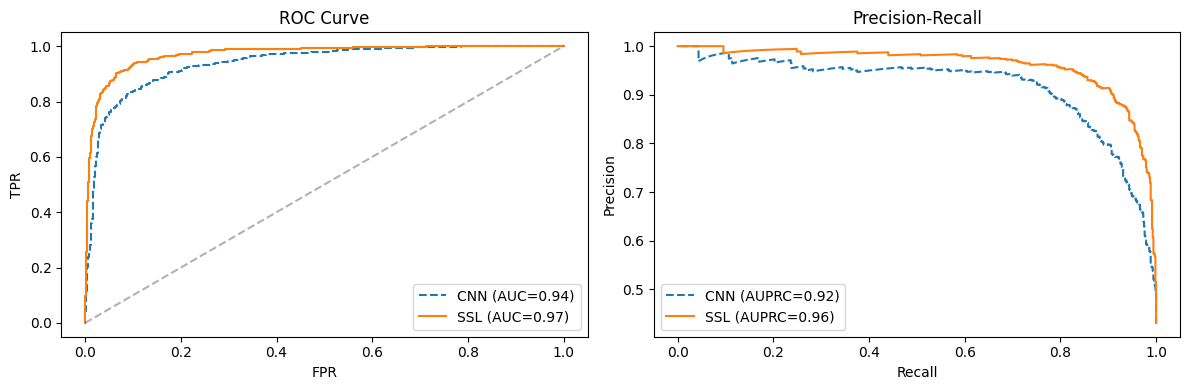

CNN → AUROC: 0.9388957040512022 AUPRC: 0.9177061090838755
SSL → AUROC: 0.9719425009998067 AUPRC: 0.9621706552115381


In [ ]:
# 1.7 Comparing Results: CNN vs. SSAMBA

import numpy as np
import torch
import h5py
import pickle
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from pathlib import Path

FULL_H5 = Path(DATASET_H5)
assert FULL_H5.exists(), f'Missing FULL_H5: {FULL_H5}'

# Prepare y_true once
with h5py.File(str(FULL_H5), 'r') as f:
    if 'label_strings' in f:
        def dec(x):
            s = x.decode('utf-8', 'ignore') if isinstance(x, (bytes, bytearray)) else str(x)
            return s.split('\x00', 1)[0].strip()
        ls = [dec(s) for s in f['label_strings'][:]]
        y_full_all = (~np.array([s == 'normal' for s in ls], dtype=bool)).astype(np.int64)
    else:
        y_full_all = (f['labels'][:].sum(axis=1) > 0).astype(np.int64)

y_true = y_full_all[test_idx_full]
print('FULL test size:', len(test_idx_full))

# --- CNN Evaluation ---
# Re-define SmallCNN if needed (in case cell wasn't run)
if 'SmallCNN' not in globals():
    class SmallCNN(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.net = torch.nn.Sequential(
                torch.nn.Conv2d(1, 16, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(16, 32, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.ReLU(), torch.nn.AdaptiveAvgPool2d((1,1))
            )
            self.cls = torch.nn.Sequential(torch.nn.Flatten(), torch.nn.Linear(128, 2))
        def forward(self, x):
            return self.cls(self.net(x))

cnn_scores = None
# Check for user-trained model first, then fallback to server pre-trained
if CNN_BEST.exists():
    cnn_ckpt_path = CNN_BEST
    print(f'Using user-trained CNN: {cnn_ckpt_path}')
elif CNN_PREP_CKPT.exists():
    cnn_ckpt_path = CNN_PREP_CKPT
    print(f'Using pre-trained CNN (fallback): {cnn_ckpt_path}')
else:
    cnn_ckpt_path = None

if cnn_ckpt_path:
    ds_full = FullH5BinaryIndexDataset(FULL_H5, test_idx_full)
    dl_full = torch.utils.data.DataLoader(ds_full, batch_size=32, shuffle=False, num_workers=0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    m = SmallCNN().to(device)
    try:
        m.load_state_dict(torch.load(cnn_ckpt_path, map_location=device))
        m.eval()
        out = []
        with torch.no_grad():
            for xb, _ in dl_full:
                pb = torch.softmax(m(xb.to(device)), dim=1)[:,1].cpu().numpy()
                out.append(pb)
        cnn_scores = np.concatenate(out, axis=0)
        print('CNN scoring done.')
    except Exception as e:
        print(f'Error loading CNN checkpoint: {e}')
else:
    print('No CNN checkpoint found. Skipping CNN evaluation.')

# --- SSAMBA Evaluation ---
ssl_scores = None
# Use the path determined in the global config (user's or server's)
ssl_ckpt_path = SSL_FT_CKPT

if ssl_ckpt_path.exists():
    print(f'Using SSAMBA checkpoint: {ssl_ckpt_path}')
    import sys
    sys.path.insert(0, str(REPO_DIR / 'src'))
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Determine args to use
    args_to_use = None
    if 'args' in globals():
        args_to_use = args
    elif 'SSL_FT_ARGS' in globals() and SSL_FT_ARGS.exists():
        print(f'Loading args from {SSL_FT_ARGS}')
        try:
            with open(SSL_FT_ARGS, 'rb') as f:
                args_to_use = pickle.load(f)
        except Exception as e:
            print(f'Error loading args: {e}')
    
    if args_to_use:
        model = create_model(args_to_use).to(device)
        try:
            checkpoint = torch.load(ssl_ckpt_path, map_location=device)
            if 'model_state_dict' in checkpoint:
                state_dict = checkpoint['model_state_dict']
            else:
                state_dict = checkpoint
            
            model.load_state_dict(state_dict)
            model.eval()
            ds_full = FullH5BinaryIndexDataset(FULL_H5, test_idx_full)
            dl_full = torch.utils.data.DataLoader(ds_full, batch_size=16, shuffle=False, num_workers=0)
            out = []
            with torch.no_grad():
                for xb, _ in dl_full:
                    # 'ft_avgtok' is the fine-tuning head
                    p = torch.sigmoid(model(xb.to(device), 'ft_avgtok')).flatten().cpu().numpy()
                    out.append(p)
            ssl_scores = np.concatenate(out, axis=0)
            print('SSAMBA scoring done.')
        except Exception as e:
            print(f'Error loading SSAMBA checkpoint: {e}')
    else:
        print('"args" variable missing and could not be loaded. Cannot recreate SSAMBA model.')
else:
    print(f'SSAMBA checkpoint not found at {ssl_ckpt_path}. Skipping SSAMBA evaluation.')


# --- Plotting ---
plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
if cnn_scores is not None:
    fpr_cnn, tpr_cnn, _ = roc_curve(y_true, cnn_scores)
    auc_cnn = auc(fpr_cnn, tpr_cnn)
    plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={auc_cnn:.3f})', linestyle='--', linewidth=2)

if ssl_scores is not None:
    fpr_ssl, tpr_ssl, _ = roc_curve(y_true, ssl_scores)
    auc_ssl = auc(fpr_ssl, tpr_ssl)
    plt.plot(fpr_ssl, tpr_ssl, label=f'SSAMBA (AUC={auc_ssl:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Precision-Recall Curve
plt.subplot(1, 2, 2)
if cnn_scores is not None:
    prec_cnn, rec_cnn, _ = precision_recall_curve(y_true, cnn_scores)
    auprc_cnn = auc(rec_cnn, prec_cnn)
    plt.plot(rec_cnn, prec_cnn, label=f'CNN (AUPRC={auprc_cnn:.3f})', linestyle='--', linewidth=2)

if ssl_scores is not None:
    prec_ssl, rec_ssl, _ = precision_recall_curve(y_true, ssl_scores)
    auprc_ssl = auc(rec_ssl, prec_ssl)
    plt.plot(rec_ssl, prec_ssl, label=f'SSAMBA (AUPRC={auprc_ssl:.3f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n--- Summary Results ---")
if cnn_scores is not None:
    print(f"CNN    -> AUROC: {auc_cnn:.4f} | AUPRC: {auprc_cnn:.4f}")
if ssl_scores is not None:
    print(f"SSAMBA -> AUROC: {auc_ssl:.4f} | AUPRC: {auprc_ssl:.4f}")


<a id="part-2-build-your-own-onc-dataset"></a>

## Part 2 Build your own ONC dataset

Ready for the gritty part: we walk through picking a hydrophone, grabbing MAT/FLAC files, labeling spectrograms, and packing everything into HDF5 splits.
Each subsection below drills into a small chunk (downloads, labeling, spectrograms, splits) so you can jump straight to the bit you need without scrolling.


<a id="21-list-active-hydrophones-and-choose-a-device"></a>

### 2.1 List active hydrophones and choose a device

Query ONC deployments via `HydrophoneDeploymentChecker`, highlight devices with fresh data, and pick your target `device_code`/date range before downloading.


<a id="22-download-mat-and-audio-flac-from-onc"></a>

### 2.2 Download MAT and audio (FLAC) from ONC

Once you have a device and date range in mind, use the ONC client to submit download jobs for spectrogram MAT files (and optionally the matching FLAC audio) across that window.

Fetch ONC hydrophones with ongoing deployments and show recent data availability (last 7 days) to help you pick a device/date range.


In [5]:
import os
from datetime import datetime, timedelta, timezone
import logging

# Use ONC_TOKEN from the global config cell
if not ONC_TOKEN:
    print('Set ONC_TOKEN in the global config cell to list active hydrophones.')
else:
    from utils.data.deployment_checker import HydrophoneDeploymentChecker
    # Quiet onc client logs if the logger is present
    try:
        logging.getLogger('onc').setLevel(logging.ERROR)
    except Exception:
        pass

    checker = HydrophoneDeploymentChecker(ONC_TOKEN, debug=False)

    # Get all deployments
    deployments = checker.get_all_hydrophone_deployments()

    # Filter to active (ongoing) deployments
    now = datetime.now(timezone.utc)
    active = [d for d in deployments if d.begin_date <= now and (d.end_date is None or d.end_date >= now)]

    # Group active by location (do not filter out by availability)
    from collections import defaultdict
    by_location_active = defaultdict(list)
    for dep in active:
        by_location_active[dep.location_name or dep.location_code].append(dep)

    # Optionally check recent data availability window (last 7 days) to annotate
    available_set = set()
    try:
        start = now - timedelta(days=7)
        available_active = checker.check_data_availability(active, start, now, check_archive=True)
        available_set = {d.device_code for d in available_active}
    except Exception as e:
        print('Availability check skipped:', e)
    


Fetching deployments: 94/94


{'dateFrom': '2025-10-24T17:21:52.000Z',
 'dateTo': '2025-10-31T17:21:52.000Z',
 'deviceCode': 'ICLISTENHF1560',
 'method': 'getListByDevice',
 'returnOptions': 'all'},
there are several warning messages:
* deviceCode: ICLISTENHF1560 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.

{'dateFrom': '2025-10-24T17:21:52.000Z',
 'dateTo': '2025-10-31T17:21:52.000Z',
 'deviceCode': 'ICLISTENAF2548',
 'method': 'getListByDevice',
 'returnOptions': 'all'},
there are several warning messages:
* deviceCode: ICLISTENAF2548 has data res

Checking data availability: 27/34

{'dateFrom': '2025-10-24T17:21:52.000Z',
 'dateTo': '2025-10-31T17:21:52.000Z',
 'deviceCode': 'ICLISTENHF6324',
 'method': 'getListByDevice',
 'returnOptions': 'all'},
there are several warning messages:
* deviceCode: ICLISTENHF6324 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.

{'dateFrom': '2025-10-24T17:21:52.000Z',
 'dateTo': '2025-10-31T17:21:52.000Z',
 'deviceCode': 'ICLISTENHF6326',
 'method': 'getListByDevice',
 'returnOptions': 'all'},
there are several warning messages:
* deviceCode: ICLISTENHF6326 has data res

{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2020-12-01T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.

{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2020-12-01T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice',
 'page': '2'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Soc

...

127.0.0.1 - - [31/Oct/2025 10:29:15] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:15] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:15] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:15] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:15] "POST /_dash-update-component HTTP/1.1" 200 -


Saved labels for ICLISTENHF6092_20221002T134000.009Z_20221002T134500.009Z-OD-spect_plotRes.mat: ['Anthropophony > Vessel', 'Instrumentation > Malfunction > Data gap']


127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:21] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:25] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:25] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:25] "POST /_dash-update-component HTTP/1.1" 204 -
127.0.0.1 - - [31/Oct/2025 10:29:25] "POST /_dash-update-component HTTP/1.1" 200 -


Saved labels for ICLISTENHF6092_20221002T134000.009Z_20221002T134500.009Z-OD-spect_plotRes.mat: ['Anthropophony > Vessel', 'Instrumentation > Malfunction > Data gap']


127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:26] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:28] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [31/Oct/2025 10:29:28] "POST /_dash-update-component HTTP/1.1" 200 -


In [6]:
from IPython.display import display
import pandas as pd

# Summary text output
total_active = sum(len(v) for v in by_location_active.values())
print(f"Active hydrophones: {total_active}")
for loc, deps in sorted(by_location_active.items()):
    print(f"\nLocation: {loc}")
    for dep in sorted(deps, key=lambda x: x.begin_date):
        end_str = dep.end_date.strftime('%Y-%m-%d') if dep.end_date else 'ongoing'
        avail_flag = ' (has data last 7d)' if dep.device_code in available_set else ''
        print(f"  - {dep.device_code}: {dep.begin_date.strftime('%Y-%m-%d')} to {end_str}{avail_flag}")

# Tabular view (more reliable display in some notebook frontends)
rows = []
for loc, deps in by_location_active.items():
    for dep in deps:
        rows.append({
            'location': loc,
            'device_code': dep.device_code,
            'begin': dep.begin_date.strftime('%Y-%m-%d'),
            'end': dep.end_date.strftime('%Y-%m-%d') if dep.end_date else 'ongoing',
            'available_last_7d': dep.device_code in available_set
        })
if rows:
    df = pd.DataFrame(rows).sort_values(['location','device_code','begin'])
    display(df)
else:
    print('No active deployments found.')

,location,device_code,begin,end,available_last_7d
11,Burrard Inlet Underwater Network,ICLISTENHF1354,2025-01-25,ongoing,True
31,Cambridge Bay Underwater Network,ICLISTENHF1951,2024-08-29,ongoing,True
32,Campbell River Underwater Network,ICLISTENHF6017,2025-08-01,ongoing,True
24,China Creek Underwater Network,ICLISTENHF1561,2025-06-05,ongoing,True
2,Digby Island Underwater Network,ICLISTENHF1252,2025-09-12,ongoing,True
10,Folger Deep,ICLISTENHF1266,2020-03-08,ongoing,True
1,Hartley Bay Underwater Network,ICLISTENAF2548,2025-09-11,ongoing,False
30,Holyrood Bay Underwater Network,ICLISTENHF2098,2023-12-13,ongoing,True
3,Hydrophone A,ICLISTENHF1332,2024-03-12,ongoing,False
5,Hydrophone A,ICLISTENHF1953,2023-07-14,ongoing,True


<a id="23-parallel-mat-downloads-advanced"></a>

### 2.3 Parallel MAT downloads (advanced)

Stream logs while launching multi-threaded MAT/FLAC downloads using `SpectrogramDownloader`—ideal once you already know which hydrophone and dates you want.


In [ ]:
# 2.3 Parallel MAT downloads advanced
import sys, time, logging
from datetime import datetime, timedelta, date as date_cls, timezone
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

# Ensure live log streaming
try:
    logging.basicConfig(level=logging.INFO, stream=sys.stdout, force=True)
except TypeError:
    for h in list(logging.root.handlers):
        logging.root.removeHandler(h)
    logging.basicConfig(level=logging.INFO, stream=sys.stdout)
logging.getLogger('onc').setLevel(logging.INFO)

if not ONC_TOKEN:
    print('Set ONC_TOKEN in the global config cell to enable ONC downloads.')
else:
    from utils.data.spectrogram_downloader import SpectrogramDownloader
    
    # Config (edit as needed)
    device_code = 'ICLISTENHF6020'
    start_date_tuple = (2020, 10, 2)  # (YYYY, MM, DD)
    num_days = 120                   # None = up to today
    threshold = 200                    # total 5-min spectrograms to collect
    per_request = 6                   # 6 x 5min per request
    max_wait_minutes = 30             # max polling time
    poll_interval_seconds = 20        # pause between poll passes
    max_download_workers = 4          # parallel downloads in poll loop

    dl = SpectrogramDownloader(ONC_TOKEN, str(DATA_DIR / 'onc'))

    # Generate sampling schedule (list of datetimes) matching the desired total
    logging.info('Generating sampling schedule...')
    year, month, day = start_date_tuple
    dt_list, _sample_span = dl.sampling_schedule(
        device_code, threshold, year, month, day,
        num_days=num_days, spectrograms_per_batch=per_request
    )
    if not dt_list:
        raise SystemExit('No sampling dates produced; adjust start_date/threshold.')

    # Directory setup using actual date span for nice folder naming
    actual_start = min(dt_list).date()
    actual_end = max(dt_list).date()
    duration_seconds = (per_request * 300) - 1
    dl.setup_directories(
        filetype='mat',
        device_code=device_code,
        download_method='parallel_sampling',
        start_date=(actual_start.year, actual_start.month, actual_start.day),
        end_date=(actual_end.year, actual_end.month, actual_end.day),
        duration_seconds=duration_seconds,
    )

    # 1) Submit all requests without waiting
    logging.info(f'Submitting {len(dt_list)} runs (no wait)...')
    run_records = []
    for ts in dt_list:
        end_dt = ts + timedelta(seconds=duration_seconds)
        rec = dl.submit_mat_run_no_wait(
            deviceCode=device_code,
            start_dt=ts,
            end_dt=end_dt,
            spectrograms_per_batch=per_request,
        )
        run_records.append(rec)
    dl.save_runs('workshop', run_records)
    logging.info('All runs submitted.')

    # 2) Poll in parallel until downloaded or timeout
    def outstanding():
        return [r for r in run_records if r.get('status') != 'downloaded']

    deadline = time.time() + max_wait_minutes * 60
    pass_num = 0
    while time.time() < deadline and outstanding():
        pass_num += 1
        todo = outstanding()
        print(f'Poll pass {pass_num}: trying {len(todo)} runs...', flush=True)
        with ThreadPoolExecutor(max_workers=max_download_workers) as ex:
            futures = {ex.submit(dl.try_download_run, r): r for r in todo}
            for fu in as_completed(futures):
                try:
                    status, updated = fu.result()
                    # update list in-place
                    for i, r in enumerate(run_records):
                        if r.get('dpRequestId') == updated.get('dpRequestId'):
                            run_records[i] = updated
                            break
                except Exception as e:
                    base = futures[fu]
                    print(f'Error in poll: dpRequestId={base.get("dpRequestId")} err={e}', flush=True)
        dl.save_runs('workshop', run_records)
        if outstanding():
            time.sleep(poll_interval_seconds)

    # Summary
    total = len(run_records)
    done = sum(1 for r in run_records if r.get('status') == 'downloaded')
    pend = total - done
    print(f'Parallel download complete → downloaded={done}/{total}, pending={pend}')
    print('Processed folder:', dl.processed_path)



INFO:root:Generating sampling schedule...
{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2021-01-30T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.

Data quantity is greater than the row limit and will be downloaded in multiple pages.
Estimated approx. 5 pages in total.
Estimated approx. 21 seconds to complete for the rest of the pages.

   (60089 samples) Downloading page 2.

<a id="24-label-spectrograms-with-the-dash-app"></a>

### 2.4 Label spectrograms with the Dash app

This starts the Dash labeling tool on localhost and optionally embeds it below.

- Set `LABEL_SPEC_DIR` to your spectrogram folder (e.g., output from 2.1 or 2.3)
- Optionally set `LABEL_AUDIO_DIR` for audio playback (e.g., FLAC downloaded by the ONC client)
- Set `LABEL_OUTPUT_FILE` to where labels should be saved


In [9]:
import os, sys, subprocess, time
from pathlib import Path
from IPython.display import IFrame, display

# Configure labeling app paths from previous cells
if 'dl' in globals() and hasattr(dl, 'processed_path'):
    LABEL_SPEC_DIR = Path(dl.processed_path)
    LABEL_AUDIO_DIR = Path(dl.flac_path) if hasattr(dl, 'flac_path') else None
else:
    # Fallbacks if no downloader was run; user can override
    try:
        LABEL_SPEC_DIR = Path(DATA_DIR)
    except NameError:
        LABEL_SPEC_DIR = Path.cwd()
    LABEL_AUDIO_DIR = None

LABEL_OUTPUT_FILE = REPO_DIR / 'notebooks' / 'labels' / 'labels.json'

# Ensure output directory exists
LABEL_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

# Launch Dash app as a background process (port 8050)
labeling_dir = REPO_DIR / 'tools' / 'labeling'

env = os.environ.copy()
# Build CLI args for config overrides
args = [
    sys.executable,
    str(labeling_dir / 'run.py'),
    '--folder', str(LABEL_SPEC_DIR),
    '--output_file', str(LABEL_OUTPUT_FILE)
]
if LABEL_AUDIO_DIR:
    args += ['--audio_folder', str(LABEL_AUDIO_DIR)]

print('Starting labeling app...')
proc = subprocess.Popen(args, cwd=str(labeling_dir), env=env)
# Give the server a moment to start
time.sleep(3)

# Display the app inline if possible
try:
    display(IFrame(src='http://127.0.0.1:8050', width='100%', height=800))
except Exception as e:
    print('Open http://127.0.0.1:8050 in your browser.')


In [10]:
# Stop the labeling app (Dash) process
import time

if 'proc' in globals():
    try:
        if proc.poll() is None:
            print(f"Stopping labeling app (pid={proc.pid})...")
            proc.terminate()
            try:
                proc.wait(timeout=5)
                print("Labeling app terminated.")
            except Exception:
                print("Graceful terminate timed out; killing...")
                proc.kill()
                try:
                    proc.wait(timeout=5)
                    print("Labeling app killed.")
                except Exception as e2:
                    print("Kill wait failed:", e2)
        else:
            print("Labeling app process already exited.")
    except Exception as e:
        print("Error stopping process:", e)
else:
    print("No labeling app process found (run the launcher cell first).")


<a id="26-use-or-build-an-hdf5-dataset"></a>

### 2.6 Use or build an HDF5 dataset

For the workshop, a FULL HDF5 is already provided for you under `$HOME/data/datasets/...`. The notebook exposes this as `DATASET_H5`, and if you drop your own copy into `REPO_DIR/data`, that repo-local version will be used instead.

If you download your own MAT or FLAC data in Part 2, the goal is to eventually convert those into an HDF5 that follows the same structure (spectrograms + labels) so you can plug it straight into SSAMBA and the CNN.


<a id="27-create-a-fixed-train-val-test-split"></a>

### 2.7 Create a fixed train/val/test split

Derive deterministic train/val/test indices from `FULL_H5`, recompute labels if needed, and save split arrays for both CNN and SSAMBA pipelines.


In [ ]:
# 2.7. Create a fixed train/val/test split on the FULL_H5 dataset
import h5py, numpy as np
from pathlib import Path

FULL_H5 = Path(DATASET_H5)
SPLIT_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

print('Deriving fixed split from FULL_H5:', FULL_H5)
if not FULL_H5.exists():
    raise SystemExit(f'Full HDF5 not found: {FULL_H5}')

# Compute binary labels and fixed split
with h5py.File(str(FULL_H5), 'r') as f:
    N = f['spectrograms'].shape[0]
    print('Total samples:', N)
    if 'label_strings' in f:
        def dec(x):
            return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
        ls = [dec(s) for s in f['label_strings'][:]]
        is_normal = np.array([s == 'normal' for s in ls], dtype=bool)
    else:
        labels = f['labels'][:]
        is_normal = (labels.sum(axis=1) == 0)

a = np.arange(N, dtype=np.int64)
rng = np.random.RandomState(SPLIT_SEED)
rng.shuffle(a)

n_train = int(TRAIN_RATIO * N)
n_val = int(VAL_RATIO * N)
train_idx = a[:n_train]
val_idx   = a[n_train:n_train+n_val]
test_idx  = a[n_train+n_val:]

print(f'Split sizes → train:{len(train_idx)}, val:{len(val_idx)}, test:{len(test_idx)}')

# Save sidecar split for reproducibility
split_path = REPO_DIR / 'data' / f'full_split_seed{SPLIT_SEED}.npz'
split_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(split_path, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
print('Saved split to:', split_path)

# Expose for later cells
FULL_TRAIN_IDX, FULL_VAL_IDX, FULL_TEST_IDX = train_idx, val_idx, test_idx



Deriving fixed split from FULL_H5: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Total samples: 16500
Split sizes → train:13200, val:1650, test:1650
Saved split to: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/full_split_seed42.npz


<a id="28-create-a-small_h5-quick-start-dataset"></a>

### 2.8 Create a SMALL_H5 quick start dataset

Sample a balanced subset of anomalies plus abundant normals from the full HDF5 to build a compact SMALL_H5 file with its own split metadata.


In [ ]:
# 2.8. Create a small balanced dataset (and fixed split) from the large HDF5

import h5py
import numpy as np
from pathlib import Path

# Use global config paths
FULL_H5 = Path(DATASET_H5)
# SMALL_H5 is defined in the global config cell; SMALL_H5_USER is always the
# repo-local target where we write a new small file if you choose to create it.

# Sampling config (fast for workshop)
# Few-shot anomalies: ~20 per anomaly class; normals much larger
SEED = 42
ANOM_PER_CLASS = 20          # target per anomaly class
NUM_NORMAL = 1000            # many normals to simulate abundant normal data
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1  # derived, but explicit for clarity

rng = np.random.RandomState(SEED)

print('Preparing SMALL dataset from:', FULL_H5)
if not FULL_H5.exists():
    print(f"Full HDF5 not found: {FULL_H5}")
else:
    with h5py.File(str(FULL_H5), 'r') as src:
        specs = src['spectrograms']
        labels = src['labels'][:]             # multi-hot
        sources = src['sources'][:] if 'sources' in src else None
        label_strings = src['label_strings'][:] if 'label_strings' in src else None

        print(f"Source shapes → spectrograms={specs.shape}, labels={labels.shape}")

        # Binary labels: normal == all zeros OR string 'normal' only
        # Prefer label_strings when present
        if label_strings is not None:
            print('Using label_strings for normal/anomalous split...')
            def dec(x):
                return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
            ls = [dec(s) for s in label_strings]
            is_normal = np.array([(s == 'normal') for s in ls], dtype=bool)
        else:
            print('Using multi-hot labels for normal/anomalous split...')
            is_normal = (labels.sum(axis=1) == 0)

        # Restrict selection to the union of FULL train+val (avoid leakage from test)
        if 'FULL_TRAIN_IDX' in globals() and 'FULL_VAL_IDX' in globals():
            pool = np.concatenate([FULL_TRAIN_IDX, FULL_VAL_IDX]).astype(np.int64)
            pool = np.unique(pool)
            print(f"Restricting selection to train+val pool of size {len(pool)}")
        else:
            pool = np.arange(labels.shape[0], dtype=np.int64)

        normal_idx = np.intersect1d(np.where(is_normal)[0], pool)
        anom_idx   = np.intersect1d(np.where(~is_normal)[0], pool)
        print(f"Found (in pool) → normal:{len(normal_idx)}, anomalous:{len(anom_idx)}")

        if len(normal_idx) == 0 or len(anom_idx) == 0:
            print('Dataset lacks one of the classes; adjust selection.')
        else:
            # Few-shot anomalies: pick ~ANOM_PER_CLASS per anomaly type (multi-hot columns)
            C = labels.shape[1]
            anom_union = set()
            picked_per_class = []
            for c in range(C):
                pos_c = np.intersect1d(np.where(labels[:, c] == 1)[0], pool)
                rng.shuffle(pos_c)
                take_c = pos_c[:min(ANOM_PER_CLASS, len(pos_c))]
                picked_per_class.append(len(take_c))
                anom_union.update(take_c.tolist())
            anom_sel = np.array(sorted(anom_union), dtype=np.int64)
            print(f"Picked anomalies per class: {picked_per_class} → unique anomalous samples: {len(anom_sel)}")

            # Many normals
            rng.shuffle(normal_idx)
            sel_normal = normal_idx[:min(NUM_NORMAL, len(normal_idx))]

            selected = np.concatenate([sel_normal, anom_sel])
            rng.shuffle(selected)

            # Build fixed split indices over selected set
            n = len(selected)
            print(f"Selected total={n} → normal={len(sel_normal)}, anomalous={len(anom_sel)}")
            n_train = int(TRAIN_RATIO * n)
            n_val   = int(VAL_RATIO * n)
            n_test  = n - n_train - n_val
            train_sel = selected[:n_train]
            val_sel   = selected[n_train:n_train+n_val]
            test_sel  = selected[n_train+n_val:]
            print(f"Split sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")
            # Debug distribution per split (using multi-hot labels)
            tr_norm = int((labels[train_sel].sum(axis=1) == 0).sum()); tr_anom = len(train_sel) - tr_norm
            va_norm = int((labels[val_sel].sum(axis=1) == 0).sum());   va_anom = len(val_sel) - va_norm
            te_norm = int((labels[test_sel].sum(axis=1) == 0).sum());  te_anom = len(test_sel) - te_norm
            print(f"Train split: normal={tr_norm}, anomalous={tr_anom}")
            print(f"Val split:   normal={va_norm}, anomalous={va_anom}")
            print(f"Test split:  normal={te_norm}, anomalous={te_anom}")

            # Create small H5 (idempotent overwrite) in your repo
            out_small = SMALL_H5_USER
            if out_small.exists():
                print(f"Overwriting existing file: {out_small}")
                out_small.unlink()
            with h5py.File(str(out_small), 'w') as dst:
                print('Creating output file and copying metadata...')
                # Allocate spectrograms dataset first
                dset = dst.create_dataset('spectrograms', shape=(n, 512, 512, 1), dtype=np.float32, compression='gzip', compression_opts=4, chunks=(64, 512, 512, 1))
                # Also copy labels/strings for reference
                dst.create_dataset('labels', data=labels[selected], dtype=labels.dtype)
                if label_strings is not None:
                    # Save as fixed-length ASCII to avoid variable-length overhead
                    maxlen = int(np.max([len(str(s)) for s in label_strings[selected]])) if len(selected) > 0 else 10
                    lbl_arr = np.array([str(s).encode('utf-8') for s in label_strings[selected]], dtype=f'S{maxlen}')
                    dst.create_dataset('label_strings', data=lbl_arr)
                if sources is not None:
                    maxlen_src = int(np.max([len(str(s)) for s in sources[selected]])) if len(selected) > 0 else 10
                    src_arr = np.array([str(s).encode('utf-8') for s in sources[selected]], dtype=f'S{maxlen_src}')
                    dst.create_dataset('sources', data=src_arr)

                # Store split indices relative to this small file (0..n-1)
                # We will persist the mapping from small indices back to original indices, too
                inv_map = {orig: i for i, orig in enumerate(selected.tolist())}
                dst.create_dataset('index_map_original', data=selected, dtype=np.int64)
                dst.create_dataset('split/train_idx', data=np.array([inv_map[i] for i in train_sel], dtype=np.int64))
                dst.create_dataset('split/val_idx', data=np.array([inv_map[i] for i in val_sel], dtype=np.int64))
                dst.create_dataset('split/test_idx', data=np.array([inv_map[i] for i in test_sel], dtype=np.int64))
                dst.attrs['seed'] = SEED
                dst.attrs['train_ratio'] = TRAIN_RATIO
                dst.attrs['val_ratio'] = VAL_RATIO
                dst.attrs['test_ratio'] = TEST_RATIO

                # Copy spectrograms last, in batches for speed
                print('Copying spectrograms in batches...')
                batch_size = 64
                num_batches = (n + batch_size - 1) // batch_size
                for b in range(num_batches):
                    s = b * batch_size
                    e = min(n, (b + 1) * batch_size)
                    idx_block = selected[s:e]
                    # h5py requires indices in increasing order; read sorted then restore original order
                    sorted_idx = np.sort(idx_block)
                    block = specs[sorted_idx]
                    order = np.searchsorted(sorted_idx, idx_block)
                    dset[s:e] = block[order]
                    if (b % 5 == 0) or (b == num_batches - 1):
                        print(f"  wrote {e}/{n} ({int(100*e/n)}%)", flush=True)

            print(f"Wrote small dataset: {out_small}")
            print(f"Sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")


Preparing SMALL dataset from: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Source shapes → spectrograms=(16500, 512, 512, 1), labels=(16500, 8)
Using label_strings for normal/anomalous split...
Restricting selection to train+val pool of size 14850
Found (in pool) → normal:8491, anomalous:6359
Picked anomalies per class: [20, 20, 20, 20, 20, 20, 20, 20] → unique anomalous samples: 158
Selected total=1158 → normal=1000, anomalous=158
Split sizes → train:926, val:115, test:117
Train split: normal=799, anomalous=127
Val split:   normal=98, anomalous=17
Test split:  normal=103, anomalous=14
Overwriting existing file: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel_SMALL.h5
Creating output file and copying metadata...
Copying spectrograms in batches...
  wrote 64/1158 (5%)
  wrote 384/1158 (33%)
  wrote 704/1158 (60%)
  wrote 1024/1158 (88%)
  wrote 1158

<a id="25-make-your-own-spectrograms-from-flac-audio"></a>

### 2.5 Make your own spectrograms from FLAC audio

Once you have raw audio (FLAC) from ONC, you can turn it into 512×512 mel spectrograms similar to the ones used in this workshop.

The basic recipe is:
- Load the audio with `librosa` (or a similar library).
- Compute a mel spectrogram with `n_mels=512` and a hop/FFT size that gives you ~512 time frames.
- Normalize and save either as images or directly into an HDF5 file alongside labels so SSAMBA and the CNN can read them.

In practice you’ll want a small script that loops over many FLAC files, computes spectrograms, and packs them into a new HDF5 that mirrors the workshop format.


<a id="5-train-the-self-supervised-model"></a>

## 5. Train the self‑supervised model

This is an **optional deep dive**: in Part 1 we assume a pretrained SSAMBA model is available, here you can actually pre‑train it yourself (masked patch tasks) and then fine tune.

Pre‑train the SSAMBA model with a masked patch joint objective and then fine‑tune it for classification. Adjust `batch-size`, `epochs`, and dataset path as needed.

- Set `DATASET_H5` to point to your HDF5 dataset
- `EXP_DIR` is where checkpoints and logs will be written


In [ ]:
# Ensure repo src is importable for `ssamba.*`
import sys
src_path = str(REPO_DIR / 'src')
# Dedup and prepend
sys.path = [p for p in sys.path if p != src_path]
sys.path.insert(0, src_path)
print('Using src path:', src_path)


Using src path: /home/sbialek/ONC/selfsupervision_anomalies_onc/src


<a id="51-customize-the-ssl-tasks"></a>

### 5.1 Customize the SSL tasks

We define `WorkshopAMBAModel` that inherits from the original and re‑implements `mpc` and `mpg` with a clearer, commented layout. These are the methods you would want to edit if you were interested in changing the self-supervised pretraining tasks.

Note: we will not be changing these during the workshop


In [ ]:
# Re-define WorkshopAMBAModel with clearer structure, rich comments, and forward()
import torch
from ssamba.models.both_models import AMBAModel

class WorkshopAMBAModel(AMBAModel):
    """
    Workshop-focused subclass that keeps the original behavior but makes
    the self-supervised objectives (mpc/mpg) and the task switch (forward)
    explicit and easy to read/tweak.

    Patch grid intuition (F x T = 512 x 512, patch_size = 16 x 16):

        F (freq)
        512 ┌────────────────────────────────────────────────────┐
            │ 32 rows of 16-bin patches (F) × 32 cols of 16-bin │
            │ patches (T) → 32×32 = 1024 patches total          │
            │  [r0c0] [r0c1] ... [r0c31]                        │
            │  [r1c0] [r1c1] ... [r1c31]                        │
            │   ...                                             │
            │  [r31c0] ...                  [r31c31]            │
            └────────────────────────────────────────────────────┘ 0
               0                    512 time → 32 cols of 16

    Flattened index idea: index(r, c) ≈ r * 32 + c.

    Masking:
    - cluster=True  → sample a c×c block (spatially coherent masking)
    - cluster=False → sample random distinct indices across the entire grid

    Why masking?
    - mpc teaches the model to identify which patch content is correct
      among negatives (discriminative InfoNCE). This encourages
      context-aware token representations.
    - mpg teaches the model to reconstruct the exact masked patch content
      (generative MSE). This encourages detailed local representations.
    """

    def mpc(self, x, mask_patch, cluster, show_mask: bool = False):
        """
        Masked Patch Classification (discriminative objective)

        High-level:
        1) Unfold spectrogram into flattened 16×16 patches → targets for masking.
        2) Choose mask indices (clustered vs random) to hide some patches.
        3) Replace the corresponding token embeddings with a learnable mask vector.
        4) Run the backbone (Vision Mamba) to produce contextualized token outputs.
        5) For each masked token, project to patch space (256 dims) and compute
           InfoNCE vs its true target patch and other negatives in the batch.

        Why InfoNCE? It forces the model to produce embeddings that are most
        similar to their correct reconstruction and dissimilar to others,
        improving contextual understanding.
        """
        # 1) Build ground-truth targets: unfold (B, 1, 512, 512) → (B, num_patches, 256)
        unfolded_targets = self.unfold(x).transpose(1, 2)
        B = x.shape[0]

        # 2) Patch-embed the input (tokens shape: B × num_patches × embed_dim)
        tokens = self.v.patch_embed(x)

        # Prepare containers for masking setup
        encode_samples = torch.empty((B, mask_patch, 256), device=tokens.device, requires_grad=False).float()
        mask_index     = torch.empty((B, mask_patch), device=tokens.device, requires_grad=False).long()
        # mask_dense acts as a per-token switch: 1 = keep original token, 0 = replace by mask token
        mask_dense     = torch.ones_like(tokens)

        # 2b) Decide which tokens to mask for each sample
        for i in range(B):
            if cluster:
                mask_index[i] = self.gen_maskid_patch(self.num_patches, mask_patch)
            else:
                mask_index[i] = self.gen_maskid_frame(self.num_patches, mask_patch)
            # Save the true (unfolded) targets for masked positions
            encode_samples[i] = unfolded_targets[i, mask_index[i], :].clone().detach()
            # Flip the switch to 0 where we will place mask tokens
            mask_dense[i, mask_index[i], :] = 0

        # 3) Replace chosen tokens by a learnable mask embedding
        mask_tokens = self.mask_embed.expand(B, tokens.shape[1], -1)
        tokens = tokens * mask_dense + (1 - mask_dense) * mask_tokens

        # 4) Add a class token and positional encoding; run the backbone for context
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)
        tokens = tokens + self.v.pos_embed
        tokens = self.v.pos_drop(tokens)

        residual = None
        hidden = tokens
        if not self.v.if_bidirectional:
            for layer in self.v.layers:
                hidden, residual = layer(hidden, residual)
        else:
            for i in range(len(self.v.layers) // 2):
                hf, rf = self.v.layers[i * 2](hidden, residual)
                hb, rb = self.v.layers[i * 2 + 1](hidden.flip([1]), None if residual is None else residual.flip([1]))
                hidden = hf + hb.flip([1])
                residual = rf + rb.flip([1])

        hidden = self.v.norm_f(hidden)

        # 5) Predict the masked tokens and compute InfoNCE
        pred = torch.empty((B, mask_patch, 256), device=hidden.device).float()
        for i in range(B):
            # +cls offset because we prepended the class token at index 0
            pred[i] = self.cpredlayer(hidden[i, mask_index[i] + self.cls_token_num, :])

        nce   = torch.tensor(0.0, device=hidden.device)
        corr  = torch.tensor(0.0, device=hidden.device)
        for i in range(B):
            # Similarity of predictions to their true targets (each sample provides negatives for the others)
            sim = torch.mm(encode_samples[i], pred[i].T)
            # Count how often the top-1 predicted index matches the correct index
            corr += torch.sum(torch.eq(torch.argmax(self.softmax(sim), dim=0), torch.arange(0, mask_patch, device=hidden.device)))
            # NCE loss (negative log probability of the correct target)
            nce  += torch.sum(torch.diag(self.lsoftmax(sim)))

        acc = 1.0 * corr / (B * mask_patch)
        nce = nce / (-1.0 * B * mask_patch)

        if not show_mask:
            return acc, nce
        else:
            # Optional visualization tensors: predicted vs masked areas folded back to 2D
            fold = torch.nn.Fold(output_size=([self.input_fdim, self.input_tdim]), kernel_size=(self.fshape, self.tshape), stride=(self.fstride, self.tstride))
            pred_map   = unfolded_targets.clone()
            masked_map = unfolded_targets.clone()
            for i in range(B):
                sim = torch.mm(encode_samples[i], pred[i].T)
                ok  = torch.eq(torch.argmax(self.softmax(sim), dim=0), torch.arange(0, mask_patch, device=hidden.device)).float() * 99
                pred_map[i, mask_index[i], :]   = ok.unsqueeze(1).expand(mask_patch, 256)
                masked_map[i, mask_index[i], :] = 99.0
            return fold(pred_map.transpose(1, 2)), fold(masked_map.transpose(1, 2))

    def mpg(self, x, mask_patch, cluster):
        """
        Masked Patch Generation (generative objective)

        High-level:
        1) Unfold spectrogram into flattened patch targets → the "ground truth" 16×16 values.
        2) Choose mask indices and replace the corresponding token embeddings with a learnable mask embedding.
        3) Run the backbone to propagate context from visible tokens to masked ones.
        4) Predict the masked patch pixel values and minimize MSE(pred, target).

        Why MSE? It forces the model to carry detailed local information so it can
        reconstruct the exact content of the masked region.
        """
        B = x.shape[0]

        # 1) Tokenize and build unfolded targets (what we want to reconstruct)
        tokens = self.v.patch_embed(x)                    # [B, num_patches, embed_dim]
        unfolded_targets = self.unfold(x).transpose(1, 2) # [B, num_patches, 256]

        # 2) Decide which tokens to mask
        mask_index = torch.empty((B, mask_patch), device=tokens.device, requires_grad=False).long()
        mask_dense = torch.ones_like(tokens)
        for i in range(B):
            mask_index[i] = self.gen_maskid_patch(self.num_patches, mask_patch) if cluster else self.gen_maskid_frame(self.num_patches, mask_patch)
            mask_dense[i, mask_index[i], :] = 0

        # Replace masked token embeddings with a learnable mask vector
        mask_tokens = self.mask_embed.expand(B, tokens.shape[1], -1)
        tokens = tokens * mask_dense + (1 - mask_dense) * mask_tokens

        # 3) Add cls + positional embeddings, then run the backbone for context
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)
        tokens = tokens + self.v.pos_embed
        tokens = self.v.pos_drop(tokens)

        residual = None
        hidden = tokens
        if not self.v.if_bidirectional:
            for layer in self.v.layers:
                hidden, residual = layer(hidden, residual)
        else:
            for i in range(len(self.v.layers) // 2):
                hf, rf = self.v.layers[i * 2](hidden, residual)
                hb, rb = self.v.layers[i * 2 + 1](hidden.flip([1]), None if residual is None else residual.flip([1]))
                hidden = hf + hb.flip([1])
                residual = rf + rb.flip([1])

        hidden = self.v.norm_f(hidden)

        # 4) Predict masked patch pixel values (256 = 16×16) and compute MSE
        pred   = torch.empty((B, mask_patch, self.fshape * self.tshape), device=hidden.device).float()
        target = torch.empty((B, mask_patch, self.fshape * self.tshape), device=hidden.device).float()
        for i in range(B):
            pred[i]   = self.gpredlayer(hidden[i, mask_index[i] + self.cls_token_num, :])
            target[i] = unfolded_targets[i, mask_index[i], :]

        mse = torch.mean((pred - target) ** 2)
        return mse

    def forward(self, x, task, cluster: bool = True, mask_patch: int = 400):
        """
        Task switch:
          - 'pretrain_mpc'   → discriminative masked patch classification
          - 'pretrain_mpg'   → generative masked patch reconstruction
          - 'pretrain_joint' → both; return (acc, mse) in validation, (acc, loss) in train
          - 'visualize_mask' → return visualization tensors for MPC
          - 'ft_*'           → finetune heads (handled in base class), requires x in (B, 1, F, T) with F=T=512

        We keep input orientation rules from the base model:
          - Finetune tasks transpose to (B, 1, F, T); pretrain tasks keep (B, 1, T, F) → but our code expects 512×512.
        """
        # Harmonize input ranks as in the base class
        if x.dim() == 3:     # (B, T, F)
            x = x.unsqueeze(1)
        elif x.dim() == 4:   # (B, H, W, C)
            if x.shape[-1] == 1:
                x = x.permute(0, 3, 1, 2)
        elif x.dim() == 5:   # (B, 1, T, F, 1)
            x = x.squeeze(-1)

        # Finetune tasks expect (B, 1, F, T); pretrain keeps original
        if task in ['ft_avgtok', 'ft_avgtok_1sec', 'ft_cls']:
            x = x.transpose(2, 3)

        B, C, T, F = x.shape
        if T != 512 or F != 512:
            raise ValueError(f'Input shape {x.shape} does not match expected shape (B, 1, 512, 512)')
        if C != 1:
            raise ValueError(f'Expected 1 channel but got {C} channels')

        if task == 'pretrain_mpc':
            return self.mpc(x, mask_patch=mask_patch, cluster=cluster)
        elif task == 'pretrain_mpg':
            return self.mpg(x, mask_patch=mask_patch, cluster=cluster)
        elif task == 'pretrain_joint':
            acc, _ = self.mpc(x, mask_patch=mask_patch, cluster=cluster)
            mse    = self.mpg(x, mask_patch=mask_patch, cluster=cluster)
            return acc, mse
        elif task == 'visualize_mask':
            return self.mpc(x, mask_patch=mask_patch, cluster=cluster, show_mask=True)
        elif task in ['ft_avgtok', 'ft_avgtok_1sec', 'ft_cls']:
            # Delegate to base finetune heads
            return super().forward(x, task, cluster=cluster, mask_patch=mask_patch)
        else:
            raise ValueError(f"Task '{task}' not recognized.")


In [ ]:
%%bash
REPO_DIR="$(git rev-parse --show-toplevel)"

# Prefer your copy of the FULL H5 in the repo, fall back to the server copy
REPO_DATASET="$REPO_DIR/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5"
SERVER_DATASET="$HOME/data/datasets/different_locations_incl_backgroundpipelinenormals_multilabel.h5"

if [ -f "$REPO_DATASET" ]; then
  DATASET_H5="$REPO_DATASET"
elif [ -f "$SERVER_DATASET" ]; then
  DATASET_H5="$SERVER_DATASET"
else
  echo "Could not find FULL HDF5 in repo or \$HOME/data/datasets; run the earlier dataset prep cells or ask your host."
  exit 1
fi

EXP_DIR="$REPO_DIR/ssamba_experiments"
mkdir -p "$EXP_DIR"

python3 "$REPO_DIR/src/run_amba_spectrogram.py" \
  --data-train "$DATASET_H5" \
  --task pretrain_joint \
  --batch-size 8 \
  --n-epochs 3 \
  --train_ratio 0.8 \
  --val_ratio 0.1 \
  --target_length 512 \
  --num_mel_bins 512 \
  --fshape 16 --tshape 16 --fstride 16 --tstride 16 \
  --num_classes 0 \
  --exp-dir "$EXP_DIR" \
  --dataset_mean 0.0 --dataset_std 1.0

/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


VisionMamba imported successfully
RMSNorm imported successfully
I am process 79514, running on ONC002458: starting (Fri Oct 24 17:03:16 2025)
[DEBUG] Parsed args: exp_dir=/home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments, data_train=/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5, task=pretrain_joint, resume=False, num_classes=0, multiclass=False
[DEBUG] Ensured exp dirs exist: /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments
[DEBUG] CWD: /home/sbialek/ONC/selfsupervision_anomalies_onc/notebooks
[DEBUG] List exp_dir: ['args.pkl', 'models', 'predictions']

Dataset split ratios:
Train: 80.0%
Val: 10.0%
Test: 10.0%
Using random seed: 42
Creating train/val/test splits from ONC dataset
Excluding labels: None

=== DATASET CONFIGURATION ===
Data path: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Split ratios - Train: 

Traceback (most recent call last):
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/run_amba_spectrogram.py", line 445, in <module>
    trainmask(None, train_loader, val_loader, args)
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/ssamba/traintest_mask.py", line 75, in trainmask
    global_step, train_metrics = training_loop(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/ssamba/utilities/training_utils.py", line 485, in training_loop
    loss.backward()
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/_tensor.py", line 648, in backward
    torch.autograd.backward(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/autograd/__init__.py", line 353, in backward
    _engine_run_backward(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/autograd/graph.py", line 824, in _engine_run_backward
    return Variable._exe

In [ ]:
%%bash
set -e
REPO_DIR="$(git rev-parse --show-toplevel)"

# Prefer your copy of the FULL H5 in the repo, fall back to the server copy
REPO_DATASET="$REPO_DIR/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5"
SERVER_DATASET="$HOME/data/datasets/different_locations_incl_backgroundpipelinenormals_multilabel.h5"

if [ -f "$REPO_DATASET" ]; then
  DATASET_H5="$REPO_DATASET"
elif [ -f "$SERVER_DATASET" ]; then
  DATASET_H5="$SERVER_DATASET"
else
  echo "Could not find FULL HDF5 in repo or \$HOME/data/datasets; run the earlier dataset prep cells or ask your host."
  exit 1
fi

EXP_DIR="$REPO_DIR/ssamba_experiments"
PRETRAINED_PATH="$EXP_DIR/models/pretrain-best.pth"  # Update with your pretrained SSL checkpoint file

python3 "$REPO_DIR/src/run_amba_spectrogram.py" \
    --data-train "$DATASET_H5" \
    --task ft_avgtok \
    --pretrained_path "$PRETRAINED_PATH" \
    --batch-size 8 \
    --n-epochs 3 \
    --train_ratio 0.8 \
    --val_ratio 0.1 \
    --target_length 512 \
    --num_mel_bins 512 \
    --fshape 16 \
    --tshape 16 \
    --fstride 16 \
    --tstride 16 \
    --exp-dir "$EXP_DIR"


<a id="7-evaluate-your-own-audio-file-local-path"></a>

## 7. Evaluate your own audio file (local path)

Set `AUDIO_PATH` to a local `.wav` (or supported) file and compute anomaly probability using a fine‑tuned SSAMBA checkpoint. Update `CHECKPOINT_PATH` to your finetuned model checkpoint (`*_best_checkpoint.pth` or similar).


In [ ]:
import torch
import numpy as np
import librosa
from pathlib import Path

# Using AUDIO_PATH and CHECKPOINT_PATH from the global config cell

# Preprocess audio to mel-spectrogram-like input matching model expectations
# NOTE: Align with training defaults: num_mel_bins=512, target_length=512
n_mels = 512
n_fft = 1024
hop_length = 512

y, sr = librosa.load(str(AUDIO_PATH), sr=None)
S = librosa.feature.melspectrogram(y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
S_db = librosa.power_to_db(S, ref=np.max)

# Normalize 0..1
S_min, S_max = S_db.min(), S_db.max()
S_norm = (S_db - S_min) / max(S_max - S_min, 1e-8)

# Pad/crop time dimension to 512 frames
T = S_norm.shape[1]
if T < 512:
    pad = 512 - T
    S_padded = np.pad(S_norm, ((0, 0), (0, pad)), mode='constant')
else:
    S_padded = S_norm[:, :512]

# Add batch and channel dims, and permute to (B, 1, F, T) for finetune tasks
x = torch.tensor(S_padded, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1, F, T)
x = x  # already (B,1,F,T); model will transpose internally for ft_* tasks

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Build model using training utilities to ensure correct config
from ssamba.utilities.training_utils import create_model
from types import SimpleNamespace

args = SimpleNamespace(
    task='ft_avgtok',
    num_mel_bins=512,
    target_length=512,
    fshape=16,
    tshape=16,
    fstride=16,
    tstride=16,
    model_size='base',
    exp_dir=str(CHECKPOINT_PATH.parent.parent),  # exp_dir/ models /
    pretrained_path=str(CHECKPOINT_PATH),
    multiclass=False,
    n_class=2,
    patch_size=16,
    stride=16,
    embed_dim=768,
    depth=24,
    channels=1,
    num_classes=2,
    drop_rate=0.0,
    drop_path_rate=0.1,
    norm_epsilon=1e-5,
    rms_norm=True,
    residual_in_fp32=True,
    fused_add_norm=True,
    if_rope=False,
    if_rope_residual=False,
    bimamba_type='v2',
    if_cls_token=True,
    if_devide_out=True,
    use_double_cls_token=False,
    use_middle_cls_token=True,
    final_pool_type='mean'
)

model = create_model(args).to(device)
model.eval()

with torch.no_grad():
    logits = model(x.to(device), args.task)
    prob = torch.sigmoid(logits).squeeze().item()
print(f"Anomaly probability: {prob:.3f}")


<a id="8-savearchive-experiment-outputs"></a>

## 8. Save/Archive experiment outputs

Create a timestamped tar.gz of the experiment directory for backup or sharing.


In [ ]:
%%bash
set -e
REPO_DIR="$(git rev-parse --show-toplevel)"
EXP_DIR="$REPO_DIR/ssamba_experiments"
TS=$(date +%Y%m%d_%H%M%S)
OUT="ssamba_experiments_${TS}.tar.gz"

if [ -d "$EXP_DIR" ]; then
  tar -czf "$OUT" -C "$(dirname "$EXP_DIR")" "$(basename "$EXP_DIR")"
  echo "Archived to $OUT"
else
  echo "Experiment directory not found: $EXP_DIR"
fi


<a id="9-roc-and-precisionrecall-curves-replace-with-actual-results"></a>

## 9. ROC and Precision‑Recall curves (replace with actual results)

Quick plotting utilities; replace placeholders with your model outputs.


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Replace these with actual results
y_true = np.random.randint(0, 2, 100)
ssl_scores = np.random.rand(100)
cnn_scores = np.random.rand(100)

fpr_ssl, tpr_ssl, _ = roc_curve(y_true, ssl_scores)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, cnn_scores)
prec_ssl, rec_ssl, _ = precision_recall_curve(y_true, ssl_scores)
prec_cnn, rec_cnn, _ = precision_recall_curve(y_true, cnn_scores)

roc_auc_ssl = auc(fpr_ssl, tpr_ssl)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
pr_auc_ssl = auc(rec_ssl, prec_ssl)
pr_auc_cnn = auc(rec_cnn, prec_cnn)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr_ssl, tpr_ssl, label=f'SSL (AUC={roc_auc_ssl:.2f})')
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={roc_auc_cnn:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rec_ssl, prec_ssl, label=f'SSL (AUPRC={pr_auc_ssl:.2f})')
plt.plot(rec_cnn, prec_cnn, label=f'CNN (AUPRC={pr_auc_cnn:.2f})', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


<a id="10-next-steps-and-resources"></a>

## 10. Next steps and resources

- Try other SSAMBA tasks (`pretrain_mpc`, `pretrain_mpg`) and fine‑tuning strategies (`ft_cls`).
- Tune hyperparameters: batch size, learning rate, and epochs.
- Use the interactive labeling tool in `tools/labeling/run.py` to expand labeled data.
- For larger experiments, prefer a machine with full CUDA toolkit and more VRAM.

Further reading
- See repository README for tasks and model usage.
- Dataset prep details in `src/ssamba/dataset.py`.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# Replace this with actual HDF5 loading code

def load_dataset():
    num_samples = 100
    num_classes = 2
    X = np.random.randn(num_samples, 1, 128, 128).astype(np.float32)
    y = np.random.randint(0, num_classes, size=num_samples)
    return X, y

class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64, num_classes))
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def prepare_dataloaders(batch_size=16, val_ratio=0.1, test_ratio=0.1):
    X, y = load_dataset()
    dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
    total = len(dataset)
    n_val = int(val_ratio * total)
    n_test = int(test_ratio * total)
    n_train = total - n_val - n_test
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])
    return DataLoader(train_set, batch_size=batch_size, shuffle=True), DataLoader(val_set, batch_size=batch_size), DataLoader(test_set, batch_size=batch_size)

def train_model(model, train_loader, val_loader, epochs=3, lr=1e-3):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
        train_loss /= len(train_loader.dataset)
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb)
                loss = loss_fn(preds, yb)
                val_loss += loss.item() * Xb.size(0)
                correct += (preds.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)
        val_loss /= len(val_loader.dataset)
        print(f'Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={correct/total:.4f}')
    return model

def evaluate_model(model, test_loader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            logits = model(Xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_score.extend(probs)
            y_true.extend(yb.numpy())
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, (y_score > 0.5).astype(int))
    return auc_roc, auc_pr, cm

train_loader, val_loader, test_loader = prepare_dataloaders()
cnn_model = SmallCNN()
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=3)
roc_auc, pr_auc, cm = evaluate_model(cnn_model, test_loader)
print(f'Supervised CNN → ROC AUC: {roc_auc:.3f}, AUPRC: {pr_auc:.3f}')
print('Confusion Matrix:\n', cm)
